# 01 — EDA: CVE Severity Triage

Разведочный анализ NVD (2024+2025), классы **low / medium / high**.

Перед запуском: python -m src.data

In [1]:
import sys
from pathlib import Path
for p in [Path.cwd(), Path.cwd().parent]:
    if (p / 'src').exists():
        sys.path.insert(0, str(p.resolve()))
        break

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.load_nvd import load_processed_dataset
from src.utils.config import load_config, resolve_path

cfg = load_config()
FIGURES = resolve_path('artifacts/figures')
FIGURES.mkdir(parents=True, exist_ok=True)
sns.set_theme(style='whitegrid')
medium_min = float(cfg['data']['severity_thresholds']['medium_min'])
high_min = float(cfg['data']['severity_thresholds']['high_min'])

In [2]:
df = load_processed_dataset()
print('Размер:', df.shape)
print('Колонки:', list(df.columns))
df.head(3)

Размер: (78040, 6)
Колонки: ['cve_id', 'description', 'cvss_base_score', 'severity', 'severity_id', 'nvd_year']


,cve_id,description,cvss_base_score,severity,severity_id,nvd_year
0,CVE-2024-0001,A condition exists in FlashArray Purity whereb...,9.8,high,2,2024
1,CVE-2024-0002,A condition exists in FlashArray Purity whereb...,9.8,high,2,2024
2,CVE-2024-0003,A condition exists in FlashArray Purity whereb...,7.2,high,2,2024


In [3]:
print('=== info ===')
df.info()
print('\nПропуски:')
print(df.isna().sum())
print('\nДубликаты cve_id:', df['cve_id'].duplicated().sum())

=== info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78040 entries, 0 to 78039
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   cve_id           78040 non-null  object 
 1   description      78040 non-null  object 
 2   cvss_base_score  78040 non-null  float64
 3   severity         78040 non-null  object 
 4   severity_id      78040 non-null  int64  
 5   nvd_year         78040 non-null  int64  
dtypes: float64(1), int64(2), object(3)
memory usage: 3.6+ MB

Пропуски:
cve_id             0
description        0
cvss_base_score    0
severity           0
severity_id        0
nvd_year           0
dtype: int64

Дубликаты cve_id: 0


In [4]:
print('Баланс severity:')
print(df['severity'].value_counts())
print('\nДоли:')
print(df['severity'].value_counts(normalize=True).round(4))
print('\nCVSS describe:')
print(df['cvss_base_score'].describe().round(3))
if 'nvd_year' in df.columns:
    print('\nПо годам:')
    print(df['nvd_year'].value_counts().sort_index())

Баланс severity:
severity
high      38675
medium    37556
low        1809
Name: count, dtype: int64

Доли:
severity
high      0.4956
medium    0.4812
low       0.0232
Name: proportion, dtype: float64

CVSS describe:
count    78040.000
mean         6.922
std          1.717
min          0.000
25%          5.500
50%          6.800
75%          8.100
max         10.000
Name: cvss_base_score, dtype: float64

По годам:
nvd_year
2024    37875
2025    40165
Name: count, dtype: int64


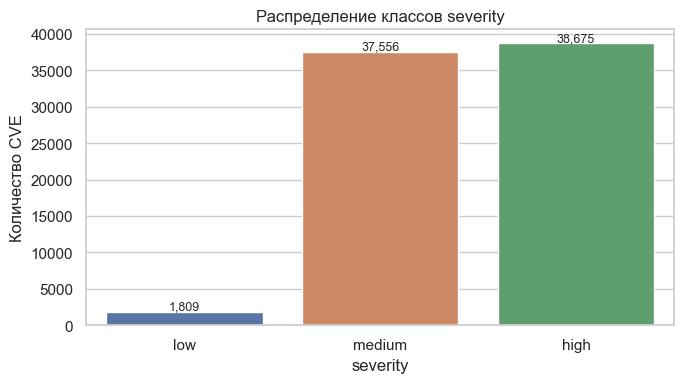

In [5]:
# severity_distribution.png
counts = df['severity'].value_counts().reindex(['low', 'medium', 'high'], fill_value=0)
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=counts.index, y=counts.values, hue=counts.index, ax=ax, legend=False)
ax.set_title('Распределение классов severity')
ax.set_ylabel('Количество CVE')
for i, v in enumerate(counts.values):
    ax.text(i, v + max(counts.values) * 0.01, f'{v:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES / 'severity_distribution.png', dpi=120)
plt.show()

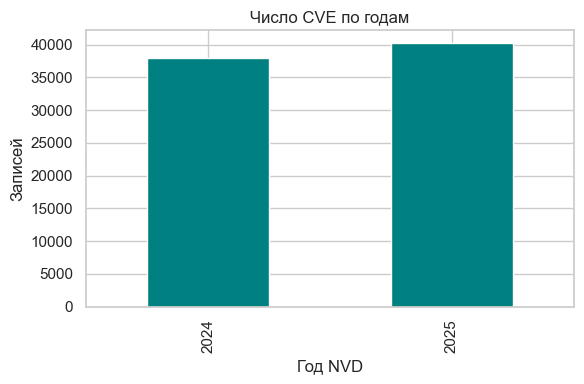

In [6]:
# records_by_year.png
if 'nvd_year' in df.columns:
    year_counts = df.groupby('nvd_year').size()
    fig, ax = plt.subplots(figsize=(6, 4))
    year_counts.plot(kind='bar', ax=ax, color='teal')
    ax.set_title('Число CVE по годам')
    ax.set_xlabel('Год NVD')
    ax.set_ylabel('Записей')
    plt.tight_layout()
    plt.savefig(FIGURES / 'records_by_year.png', dpi=120)
    plt.show()

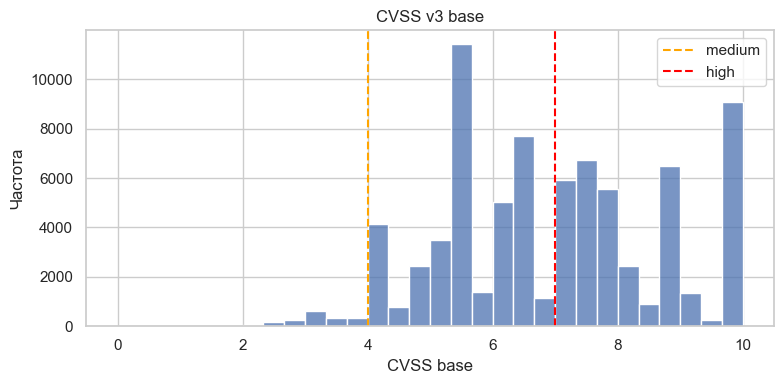

CVSS диапазон vs severity:
severity          high   low  medium
cvss_base_score                     
(-0.001, 4.0]        0  1809     128
(4.0, 7.0]         396     0   37428
(7.0, 10.0]      38279     0       0


In [ ]:
# eda_distributions.png — CVSS
df['text_len'] = df['description'].str.len()
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df['cvss_base_score'], bins=30, ax=ax)
ax.axvline(medium_min, color='orange', ls='--', label='medium')
ax.axvline(high_min, color='red', ls='--', label='high')
ax.set_title('CVSS v3 base')
ax.set_xlabel('CVSS base')
ax.set_ylabel('Частота')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES / 'eda_distributions.png', dpi=120)
plt.show()

ct = pd.crosstab(pd.cut(df['cvss_base_score'], bins=[0, 4, 7, 10], include_lowest=True), df['severity'])
print('CVSS диапазон vs severity:')
print(ct)

## Выводы EDA

- Данные: открытый NVD 2024+2025, только CVE с CVSS v3 и английским описанием.
- Метки: low (CVSS < 4), medium (4–7), high (≥ 7).
- Класс **low** редкий — при обучении нужен class_weight='balanced'.
- Графики сохранены в artifacts/figures/.